## Storytelling with Data - Freedom, Waterfall i Kierowanie Uwagą
---

Witaj na kolejnych zajęciach z wizualizacji danych! Dzisiaj kończymy naszą podróż z książką **"Storytelling with Data" (SWD)** autorstwa Cole Nussbaumer Knaflic.

Tym razem zobaczymy, w jaki sposób rozkładać zmiany na czynniki pierwsze za pomocą wykresu kaskadowego, jak skutecznie zepchnąć szum na tło, by wyeksponować głównego bohatera naszej historii, oraz jak poprawnie odróżniać dane historyczne od prognoz.

**Podczas tych zajęć nauczymy się m.in.:**
* **Forward/Backward Fill:** Zaawansowanej metody radzenia sobie z brakami w szeregach czasowych.
* **Wykresu kaskadowego (Waterfall chart):** Zbudujemy go "metodą siłową" (brute-force), o której pisze Cole.
* **Kierowania uwagą (Focus attention):** Powtórzymy jak spychać zbędne dane do szarego tła, by wybić na pierwszy plan to, co najważniejsze.

Tym razem wykorzystamy dane ze wskaźnika szczęścia (z pliku `happiness_index.csv`) i połączymy je z listą regionów (`world_data.csv`). Główna zmienna **`freedom`**, którą będziemy analizować, jest liczona w następujący sposób:
> *Are you satisfied or dissatisfied with your freedom to choose what you do with your life? (ranking)*

Jest to zmienna rankingowa, więc im jest ona **niższa tym lepiej**!

---

## Zadanie 0: Wczytywanie, mądre czyszczenie i łączenie danych

W rzeczywistych danych makroekonomicznych i społecznych często brakuje odczytów dla pojedynczych lat. Ponieważ wskaźniki rzadko zmieniają się drastycznie z dnia na dzień, świetną i bezpieczną metodą radzenia sobie z `NaN` jest **propagacja ostatniej znanej wartości do przodu (Forward Fill)**.

**Instrukcja krok po kroku:**

1. Importuj biblioteki: `pandas as pd`, `seaborn as sns`, `matplotlib.pyplot as plt`, `numpy as np`. Ustaw styl wykresów za pomocą `sns.set_theme(style="white")`.
2. Wczytaj pliki z GitHuba (używając linków "Raw"): `happiness_index.csv` oraz `world_data.csv`.
3. **Magia Pandas (Forward/Backward Fill):** Pogrupuj dane ze wskaźnikiem szczęścia po krajach i użyj metod `.ffill()` (wypełnia braki poprzednią wartością) oraz `.bfill()` (jeśli brakuje pierwszej wartości, bierze następną). Zastosuj to na kolumnie, którą będziemy analizować. Kod: `df_happiness[cols] = df_happiness.groupby('country')[cols].ffill().bfill()`.
4. **Łączenie:** Połącz tabelę ze szczęściem z kolumnami `['country', 'Region']` z tabeli o świecie używając `pd.merge()` z argumentem `how='inner'`. Zapisz to do zmiennej `df`.
5. Filtrujemy tylko od roku 2015 w górę: `df = df[df['year'] >= 2015]`. Posortuj dane i zresetuj indeks.

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.set_theme(style="white")

url_happiness = "https://raw.githubusercontent.com/tadejow/data-visualization-labs/refs/heads/main/data/happiness_index.csv"
url_world = "https://raw.githubusercontent.com/tadejow/data-visualization-labs/refs/heads/main/data/world_data.csv"

df_happiness = pd.read_csv(url_happiness)
df_world = pd.read_csv(url_world)

cols_to_fill = ['freedom']
df_happiness[cols_to_fill] = df_happiness.groupby('country')[cols_to_fill].ffill().bfill()

df = pd.merge(df_happiness, df_world[['country', 'Region']], on='country', how='inner')
df = df[df['year'] >= 2015]
df = df.sort_values(['country', 'year']).reset_index(drop=True)

numeric = ['year', 'rank', 'life evaluation', 'change (since 2012)',
       'inequality', 'social support', 'gdp per capita',
       'healthy life expectancy', 'freedom', 'generosity',
       'perceptions of corruption', 'positive emotions', 'negative emotions',
       'donated', 'volunteered', 'helped a stranger',
       'healthy life expectancy (2021 data)']

df[numeric] = df[numeric].apply(pd.to_numeric, errors='coerce')

print(f"Shape: {df.shape}")

Shape: (1187, 19)


## 1. Zadanie obowiązkowe - Wykres kaskadowy (Waterfall Chart)

*(Inspiracja: SWD, Rozdział 2 "Choosing an effective visual", str. 55-57 - w PDF str. 71-73).*

Cole Nussbaumer Knaflic podkreśla, że wykres kaskadowy to potężne narzędzie, gdy chcemy zwizualizować wartość początkową, pozytywne i negatywne zmiany oraz ostateczną wartość końcową. Taki układ często nazywany jest "mostem" (bridge). Ponieważ Seaborn nie ma wbudowanej funkcji tworzenia takich wykresów, do wykreślenia samych słupków wykorzystamy metodę "brute-force" (siłową) w Matplotlib, ale zaprzęgniemy Seaborn do ulepszenia estetyki, rysowania linii trendu oraz czyszczenia wykresu.

**Zbudujmy wykres kaskadowy pokazujący ewolucję poczucia wolności (`freedom`) dla Polski w latach 2015-2024.** Będziemy mieli pełny słupek dla 2015 r., 9 wiszących w powietrzu słupków ze zmianami rok do roku, oraz pełny słupek podsumowujący na 2024 r. Dodatkowo narysujemy ciągłą linię śledzącą ten trend (idącą w dół przy spadkach i w górę przy wzrostach).

**Instrukcja krok po kroku:**

0. **Ustawienie globalnego stylu:** Ustaw styl seaborn: `sns.set_theme(style="white", context="notebook")`.
1. **Przygotowanie danych:** Odfiltruj z ramki `df` dane dla `country == 'Poland'` oraz `year` z przedziału 2015-2024. Posortuj po roku. Wyciągnij wartości do listy: `vals = pd.to_numeric(df_pl['freedom']).tolist()`. Zauważ, że `vals` ma długość 10.
2. **Przygotowanie struktur:** Utwórz listę osi X dla 11 słupków: `x_labels = ['Start 2015'] + [f"Zmiana '{str(y)[-2:]}" for y in range(2016, 2025)] + ['Koniec 2024']`. Utwórz cztery puste listy: `bottoms`, `heights`, `colors`, `labels_txt`.
3. **Punkt startowy (Rok 2015):** Dodaj do list odpowiednio: dno `0`, wysokość `vals[0]`, kolor `'dimgrey'`, etykieta `f"{vals[0]:.3f}"`.
4. **Matematyka kaskady (Zmiany):** Ustaw zmienną bazową `current = vals[0]`. Użyj pętli po kolejnych latach `for i in range(1, len(vals)):`
   * Wylicz różnicę: `step = vals[i] - vals[i-1]`.
   * **Jeśli `step >= 0` (wzrost):** Dodaj: dno `current`, wysokość `step`, kolor `'mediumseagreen'`, etykieta `f"+{step:.3f}"`.
   * **Jeśli `step < 0` (spadek):** Matplotlib wymaga dodatniej wysokości, więc dnem staje się nowa wartość! Dodaj: dno `current + step`, wysokość `abs(step)`, kolor `'indianred'`, etykieta `f"{step:.3f}"` (zmienna `step` ma już w sobie minus).
   * Na koniec obrotu pętli zaktualizuj bazę: `current += step`.
5. **Punkt końcowy (Rok 2024):** Poza pętlą dodaj ostatni słupek: dno `0`, wysokość `vals[-1]`, kolor `'dimgrey'`, etykieta `f"{vals[-1]:.3f}"`.
6. **Rysowanie:** Wywołaj `fig, ax = plt.subplots(figsize=(14, 6))`. Stwórz `x_pos = np.arange(len(x_labels))`. Narysuj słupki (korzystając z Matplotlib, aby użyć parametru `bottom`): `ax.bar(x=x_pos, height=heights, bottom=bottoms, color=colors, width=0.65)`.
7. **Linia trendu:** Aby połączyć osie środkowe i pokazać prawdziwy kierunek zmiany, utwórzmy listę o długości 11 (wyrównującą się z naszą osią X). Ponieważ wartość po 2024 r. już się nie zmienia, kopiujemy ostatni element: `line_vals = vals + [vals[-1]]`. Narysuj linię wykorzystując Seaborn: `sns.lineplot(x=x_pos, y=line_vals, color='gray', linestyle='-', linewidth=2.5, alpha=1.0, zorder=1, ax=ax)`.
8. **Oczyszczanie (Decluttering z Seaborn):** Użyj funkcji `sns.despine(left=True, bottom=False, ax=ax)`, aby jednym ruchem usunąć niepotrzebne ramki (górną, prawą i lewą). Pokoloruj pozostawioną dolną ramkę: `ax.spines['bottom'].set_color('lightgrey')`. Wyłącz liczby na osi Y `ax.get_yaxis().set_visible(False)` i małe kreseczki na osi X `ax.tick_params(bottom=False)`. Ustaw podpisy: `ax.set_xticks(x_pos)` oraz `ax.set_xticklabels(x_labels, rotation=45, ha='right')`.
9. **Bezpośrednie etykietowanie:** Aby tekst zawsze unosił się estetycznie *nad* słupkiem niezależnie od tego czy wartości spadły czy wzrosły, wylicz absolutne wierzchołki prostokątów: `bar_tops = [b + h for b, h in zip(bottoms, heights)]`. Dodaj etykiety `ax.text(i, bar_tops[i] + 0.015, labels_txt[i], ...)`
10. **Tytuł akcji:** Dodaj tytuł podsumowujący. Wywołaj `plt.tight_layout()` i `plt.show()`.

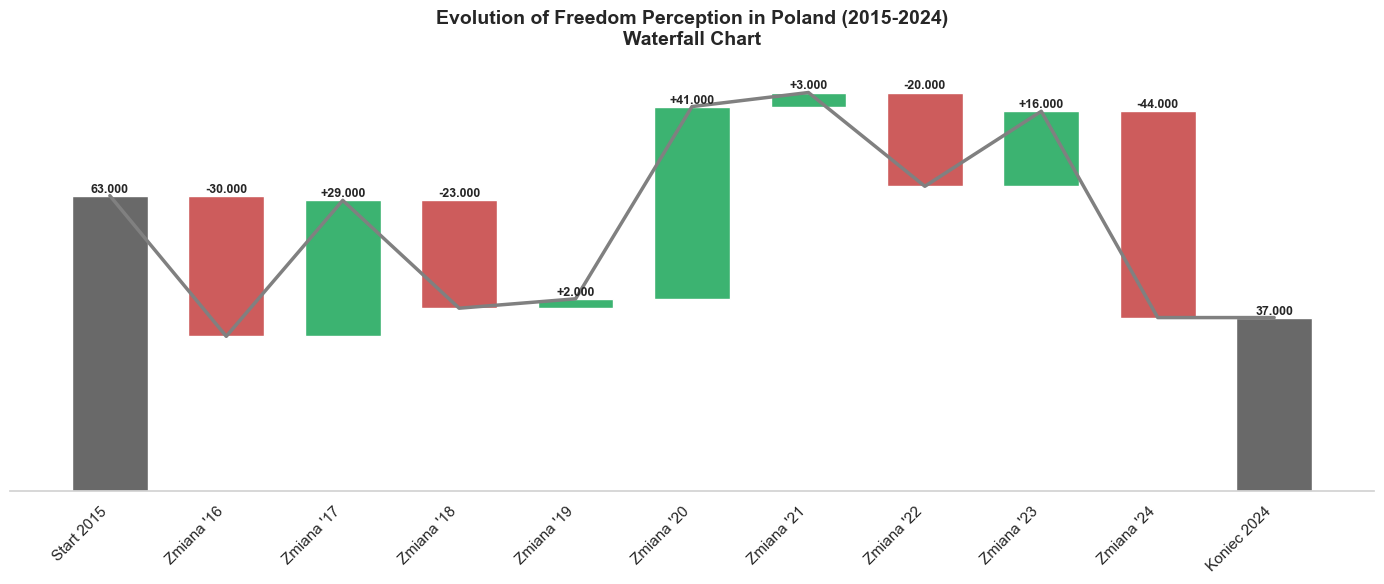

In [21]:
sns.set_theme(style="white", context="notebook")

df_pl = df[(df['country'] == 'Poland') & (df['year'].between(2015, 2024))].copy()
df_pl = df_pl.sort_values('year').reset_index(drop=True)
vals = pd.to_numeric(df_pl['freedom']).tolist()

x_labels = ['Start 2015'] + [f"Zmiana '{str(y)[-2:]}" for y in range(2016, 2025)] + ['Koniec 2024']
bottoms = []
heights = []
colors = []
labels_txt = []

bottoms.append(0)
heights.append(vals[0])
colors.append('dimgrey')
labels_txt.append(f"{vals[0]:.3f}")

current = vals[0]
for i in range(1, len(vals)):
    step = vals[i] - vals[i-1]
    
    if step >= 0:
        bottoms.append(current)
        heights.append(step)
        colors.append('mediumseagreen')
        labels_txt.append(f"+{step:.3f}")
    else:
        bottoms.append(current + step)
        heights.append(abs(step))
        colors.append('indianred')
        labels_txt.append(f"{step:.3f}")
    
    current += step

bottoms.append(0)
heights.append(vals[-1])
colors.append('dimgrey')
labels_txt.append(f"{vals[-1]:.3f}")

fig, ax = plt.subplots(figsize=(14, 6))
x_pos = np.arange(len(x_labels))
ax.bar(x=x_pos, height=heights, bottom=bottoms, color=colors, width=0.65)

line_vals = vals + [vals[-1]]
sns.lineplot(x=x_pos, y=line_vals, color='gray', linestyle='-', linewidth=2.5, alpha=1.0, zorder=1, ax=ax)

sns.despine(left=True, bottom=False, ax=ax)
ax.spines['bottom'].set_color('lightgrey')
ax.get_yaxis().set_visible(False)
ax.tick_params(bottom=False)
ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels, rotation=45, ha='right')

bar_tops = [b + h for b, h in zip(bottoms, heights)]
for i, (bar_top, label) in enumerate(zip(bar_tops, labels_txt)):
    ax.text(i, bar_top + 0.015, label, ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title('Evolution of Freedom Perception in Poland (2015-2024)\nWaterfall Chart', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_ylabel('Freedom Ranking', fontsize=11)
plt.tight_layout()
plt.show()

## 2. Zadanie dodatkowe dla chętnych: Wizualizacja Prognozy i Stożka Niepewności

W tej sekcji stworzymy jeden, wysoce dopracowany wykres łączący kilka potężnych koncepcji z książki "Storytelling with Data".

*(Inspiracja: SWD, Rozdział 6 "Dissecting model visuals", str. 154-155 oraz Rozdział 2 "Showing average within a range in a line graph", str. 46-47).*

< krótki powrót do matplotliba :) >

Cole zaznacza: *"Często widzę dane prognozowane i rzeczywiste narysowane jako jedna ciągła linia. To błąd"*. Wizualne wskazówki muszą pozwalać widzowi od razu zauważyć strefę niepewności. W tym zadaniu pokażemy historię wskaźnika poczucia wolności (`freedom`) dla **Stanów Zjednoczonych (`United States`)**.

Załóżmy (hipotetycznie), że dane do 2020 r. to nasza "twarda historia" (Actual), a od 2020 r. do 2024 r. to nasza prognoza (Forecast). Zbudujemy wykres, który:
1. Rozdziela style linii (ciągła dla przeszłości, przerywana dla prognozy).
2. Dodaje "zagrodę" – szare tło oddzielające przyszłość.
3. Wizualizuje **Stożek Niepewności** (szacowany przedział błędu prognozy, który rozszerza się w czasie).

**Instrukcja krok po kroku:**

1. **Filtrowanie danych:** Odfiltruj z ramki `df` dane dla `country == 'United States'` oraz `year` z przedziału 2015-2024. Zapisz do `df_us`.
2. **Podział na Actual i Forecast:** Zbuduj dwie ramki:
   * `df_actual` zawierającą lata `<= 2020`
   * `df_forecast` zawierającą lata `>= 2020` *(Uwaga: Rok 2020 musi być w obu, by linie połączyły się w jednym punkcie!)*
3. **Symulacja Stożka Niepewności:** Ponieważ nie mamy w danych przedziałów ufności, zasymulujemy je. Stwórz tablicę błędów, która rośnie od 0 (w 2020 r.) do 20.0 (w 2024 r.) używając funkcji: `error = np.linspace(0, 20.0, len(df_forecast))`. Następnie wylicz górną i dolną granicę prognozy: `upper_bound = df_forecast['freedom'] + error` oraz `lower_bound = df_forecast['freedom'] - error`.
4. **Inicjalizacja i Linie Główne:** Wywołaj `fig, ax = plt.subplots(figsize=(14, 7))`. Narysuj dane historyczne: `ax.plot(...)` używając koloru `'steelblue'` i `linewidth=3.5`. Narysuj prognozę: użyj tego samego koloru, ale dodaj parametr `linestyle='--'`.
5. **Rysowanie Przedziału Ufności:** Użyj funkcji `ax.fill_between(x, y1, y2, ...)`. Przekaż do niej rok z prognozy oraz wyliczone wcześniej `lower_bound` i `upper_bound`. Użyj koloru `'steelblue'`, ale z przezroczystością `alpha=0.15`, by stworzyć subtelny cień.
6. **Punkty Kotwiczące (Anchors):** Wyróżnij rok podziału (2020) oraz rok końcowy (2024). Użyj `ax.plot(rok, wartosc, marker='o', markersize=9, color='steelblue')` dla obu tych punktów.
7. **Bezpośrednie Etykietowanie Wartości:** Dodaj tekst obok punktów kotwiczących za pomocą `ax.text(...)`. Dla 2020 wpisz dokładną wartość wskaźnika, a dla 2024 wpisz wartość prognozowaną z dopiskiem "est." (np. `6.85 est.`). Zadbaj o pogrubienie fontu.
8. **Enclosure (Tło i Teksty):** Użyj `ax.axvspan(xmin=2020, xmax=2024, color='lightgrey', alpha=0.25)` by zacienić strefę przyszłości. Następnie dodaj napisy `ACTUAL` (np. na X=2017.5, Y=7.4) oraz `FORECAST` (na X=2022.5, Y=7.4) szarą, pogrubioną czcionką.
9. **Oczyszczanie (Decluttering):** Usuń ramki `top`, `right`, i `left`. Oś Y sformatuj tak, by obejmowała zakres od 0.0 do 200.0 (`ax.set_ylim`). Wyłącz znaczniki na osiach (`ax.tick_params(bottom=False, left=False)`).
10. **Zwieńczenie – Tytuł Akcji:** Dodaj tytuł: *"Oczekuje się, że ranking poczucia wolności w USA utrzyma negatywny trend, \nwyższy ranking oznacza mniejsze poczucie wolności"*. Wywołaj `plt.tight_layout()` i `plt.show()`.

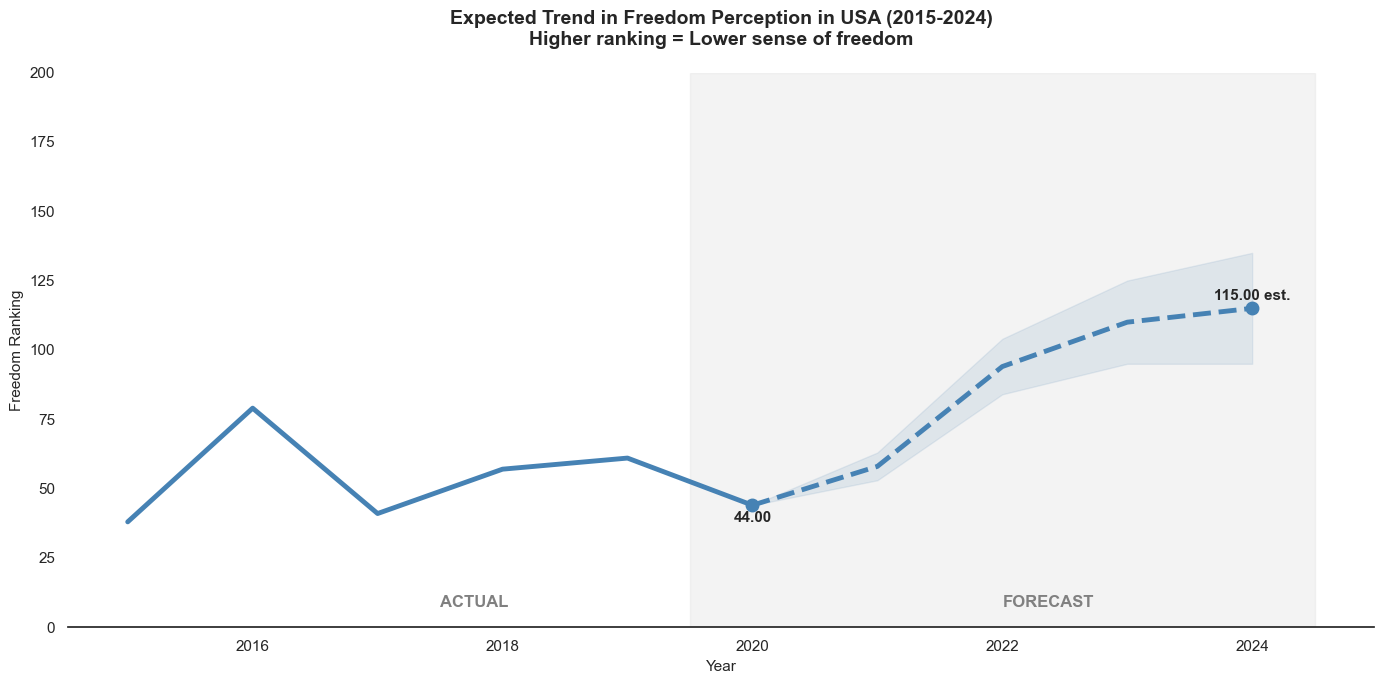

In [ ]:
df_us = df[(df['country'] == 'United States') & (df['year'].between(2015, 2024))].copy()
df_us = df_us.sort_values('year').reset_index(drop=True)

df_actual = df_us[df_us['year'] <= 2020].copy()
df_forecast = df_us[df_us['year'] >= 2020].copy()

error = np.linspace(0, 20.0, len(df_forecast))
upper_bound = df_forecast['freedom'] + error
lower_bound = df_forecast['freedom'] - error

fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(df_actual['year'], df_actual['freedom'], color='steelblue', linewidth=3.5, label='Actual')
ax.plot(df_forecast['year'], df_forecast['freedom'], color='steelblue', linewidth=3.5, 
        linestyle='--', label='Forecast')

ax.fill_between(df_forecast['year'], lower_bound, upper_bound, 
                color='steelblue', alpha=0.15, label='Uncertainty Cone')

anchor_2020_year = df_actual[df_actual['year'] == 2020]['year'].values[0]
anchor_2020_value = df_actual[df_actual['year'] == 2020]['freedom'].values[0]
anchor_2024_year = df_forecast[df_forecast['year'] == 2024]['year'].values[0]
anchor_2024_value = df_forecast[df_forecast['year'] == 2024]['freedom'].values[0]

ax.plot(anchor_2020_year, anchor_2020_value, marker='o', markersize=9, color='steelblue')
ax.plot(anchor_2024_year, anchor_2024_value, marker='o', markersize=9, color='steelblue')

ax.text(anchor_2020_year, anchor_2020_value - 2, f'{anchor_2020_value:.2f}', 
        ha='center', va='top', fontsize=11, fontweight='bold')
ax.text(anchor_2024_year, anchor_2024_value + 2, f'{anchor_2024_value:.2f} est.', 
        ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.axvspan(xmin=2019.5, xmax=2024.5, color='lightgrey', alpha=0.25)
ax.text(2017.5, 7.4, 'ACTUAL', fontsize=12, fontweight='bold', color='gray')
ax.text(2022, 7.4, 'FORECAST', fontsize=12, fontweight='bold', color='gray')

sns.despine(left=True, bottom=False, top=True, right=True, ax=ax)
ax.set_ylim(0.0, 200.0)
ax.tick_params(bottom=False, left=False)

ax.set_title('Expected Trend in Freedom Perception in USA (2015-2024)\nHigher ranking = Lower sense of freedom', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Freedom Ranking', fontsize=11)
plt.tight_layout()
plt.show()